# Day 10：收官之战 —— 从感知机到 Transformer 的觉醒之路> 🚀 第十二周 · 注意力时代 · 第 10 天这是整个 12 周课程的收官之日。今天，我们要做两件事：1. 从零搭建一个完整的迷你 Transformer，解决一个真实的序列任务2. 回顾从感知机到 Transformer 的完整旅程**今天的任务**：1. 搭建完整 MiniTransformer 并实战2. 全面回顾 12 周的核心知识3. 展望 AI 的未来---

## 1. 历史剧场：从感知机到 Transformer，70 年的觉醒让我们回顾这段波澜壮阔的历史：| 年代 | 事件 | 核心突破 ||---|---|---|| 1957 | 感知机诞生 | 第一个"人造神经元" || 1969 | XOR 危机 | AI 第一次寒冬 || 1986 | 反向传播流行 | 多层网络可训练 || 1997 | LSTM 诞生 | 序列建模的突破 || 2012 | AlexNet 夺冠 | 深度学习复兴 || 2015 | ResNet 诞生 | 深层网络可训练 || 2017 | Transformer 诞生 | 注意力替代循环 || 2018 | BERT / GPT-1 | 预训练大模型时代 || 2022 | ChatGPT | AI 走入千家万户 |每一次突破，都是因为解决了前一个时代的**核心痛点**。---

## 2. 代码实验室：完整 MiniTransformer 实战

In [ ]:
import torchimport torch.nn as nnimport torch.nn.functional as Fimport matplotlib.pyplot as pltimport numpy as npplt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']plt.rcParams['axes.unicode_minus'] = False

### 2.1 完整 MiniTransformer

In [ ]:
class PositionalEncoding(nn.Module):    def __init__(self, d_model, max_len=100):        super().__init__()        PE = torch.zeros(max_len, d_model)        pos = torch.arange(max_len).unsqueeze(1).float()        div = torch.exp(torch.arange(0, d_model, 2).float() *                       -(np.log(10000.0) / d_model))        PE[:, 0::2] = torch.sin(pos * div)        PE[:, 1::2] = torch.cos(pos * div)        self.register_buffer('PE', PE.unsqueeze(0))    def forward(self, x):        return x + self.PE[:, :x.size(1)]class MiniTransformer(nn.Module):    def __init__(self, vocab_size, d_model=64, n_heads=4,                 d_ff=256, n_layers=2, max_len=50):        super().__init__()        self.d_model = d_model        self.embedding = nn.Embedding(vocab_size, d_model)        self.pos_enc = PositionalEncoding(d_model, max_len)        self.encoder_layers = nn.ModuleList([            nn.TransformerEncoderLayer(d_model, n_heads, d_ff,                                       dropout=0.1, batch_first=True)            for _ in range(n_layers)        ])        self.decoder_layers = nn.ModuleList([            nn.TransformerDecoderLayer(d_model, n_heads, d_ff,                                       dropout=0.1, batch_first=True)            for _ in range(n_layers)        ])        self.fc_out = nn.Linear(d_model, vocab_size)        self._init_weights()    def _init_weights(self):        for p in self.parameters():            if p.dim() > 1:                nn.init.xavier_uniform_(p)    def encode(self, src):        x = self.pos_enc(self.embedding(src) * np.sqrt(self.d_model))        for layer in self.encoder_layers:            x = layer(x)        return x    def decode(self, tgt, enc_output, tgt_mask=None):        x = self.pos_enc(self.embedding(tgt) * np.sqrt(self.d_model))        for layer in self.decoder_layers:            x = layer(x, enc_output, tgt_mask=tgt_mask)        return self.fc_out(x)    def forward(self, src, tgt, tgt_mask=None):        enc_output = self.encode(src)        if tgt_mask is None:            tgt_mask = nn.Transformer.generate_square_subsequent_mask(tgt.size(1)).to(tgt.device)        output = self.decode(tgt, enc_output, tgt_mask)        return output

### 2.2 序列反转任务

In [ ]:
vocab_size = 10seq_len = 6def generate_data(n_samples=500):    src = torch.randint(1, vocab_size, (n_samples, seq_len))    tgt_input = torch.cat([torch.zeros(n_samples, 1, dtype=torch.long), src.flip(1)], dim=1)    tgt_output = torch.cat([src.flip(1), torch.zeros(n_samples, 1, dtype=torch.long)], dim=1)    return src, tgt_input, tgt_outputsrc, tgt_in, tgt_out = generate_data(500)print(f"源序列示例: {src[0].tolist()}")print(f"目标输入:   {tgt_in[0].tolist()}")print(f"目标输出:   {tgt_out[0].tolist()}")print(f"任务: 学会反转序列!")

### 2.3 训练

In [ ]:
model = MiniTransformer(vocab_size, d_model=32, n_heads=4, d_ff=128, n_layers=2)optimizer = torch.optim.Adam(model.parameters(), lr=0.001, betas=(0.9, 0.98), eps=1e-9)loss_fn = nn.CrossEntropyLoss(ignore_index=0)losses = []for epoch in range(300):    tgt_mask = nn.Transformer.generate_square_subsequent_mask(tgt_in.size(1))    output = model(src, tgt_in, tgt_mask)    loss = loss_fn(output.reshape(-1, vocab_size), tgt_out.reshape(-1))    optimizer.zero_grad()    loss.backward()    nn.utils.clip_grad_norm_(model.parameters(), 1.0)    optimizer.step()    losses.append(loss.item())    if (epoch + 1) % 50 == 0:        pred = output.argmax(dim=-1)        acc = (pred == tgt_out).float().mean()        print(f"Epoch {epoch+1:3d} | Loss: {loss.item():.4f} | Acc: {acc:.2%}")

### 2.4 测试

In [ ]:
model.eval()with torch.no_grad():    test_src = torch.randint(1, vocab_size, (5, seq_len))    current = torch.zeros(5, 1, dtype=torch.long)    for _ in range(seq_len + 1):        tgt_mask = nn.Transformer.generate_square_subsequent_mask(current.size(1))        out = model(test_src, current, tgt_mask)        next_tok = out[:, -1, :].argmax(dim=-1, keepdim=True)        current = torch.cat([current, next_tok], dim=1)print("序列反转测试：")print("-" * 40)for i in range(5):    src_seq = test_src[i].tolist()    pred_seq = current[i, 1:].tolist()    print(f"  输入: {src_seq}")    print(f"  反转: {src_seq[::-1]}")    print(f"  预测: {pred_seq[:seq_len]}")    print()

### 2.5 可视化

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))ax.plot(losses, color='#9b59b6', alpha=0.8)ax.set_xlabel('Epoch', fontsize=12)ax.set_ylabel('Loss', fontsize=12)ax.set_title('MiniTransformer 训练损失', fontsize=14)ax.grid(True, alpha=0.3)plt.tight_layout()plt.show()

---

## 3. 12 周回顾：从感知机到 Transformer### 阶段一：AI 的初春与寒冬（第 1-2 周）- **感知机**：最简单的"神经元"，只能做线性分类- **XOR 危机**：感知机无法解决异或问题 → AI 第一次寒冬- **多层感知机**：加隐藏层，解决线性不可分- **反向传播**：让多层网络可训练### 阶段二：破局与复兴（第 3-4 周）- **激活函数**：Sigmoid/ReLU 引入非线性- **损失函数与梯度下降**：模型如何"学习"### 阶段三：视觉的征服与深度的瓶颈（第 5-6 周）- **CNN**：卷积核提取特征，权值共享减少参数- **梯度消失**：深层网络训练困难### 阶段四：ResNet 的奇迹（第 7-8 周）- **退化问题**：网络越深反而越差- **残差连接**：$F(x) + x$，让深层网络可训练- **核心思想**：加法更新 = 梯度保底### 阶段五：记忆的诞生（第 9-10 周）- **RNN**：有了记忆，但只有"金鱼记忆"- **LSTM**：三个门 + 细胞状态，长距离记忆- **Seq2Seq**：Encoder-Decoder + 信息瓶颈### 阶段六：注意力时代（第 11-12 周）- **注意力机制**：Q、K、V 的三角舞- **多头注意力**：同时关注不同关系- **位置编码**：让注意力知道顺序- **Transformer**：注意力替代循环，并行替代串行- **BERT vs GPT**：理解 vs 生成---

## 4. 核心洞察：贯穿 12 周的三条线索### 线索一：信息流动- **感知机**：信息单向流动- **反向传播**：误差反向流动- **ResNet**：信息通过残差"抄近道"- **LSTM**：信息通过细胞状态"高速公路"- **Transformer**：信息通过注意力"自由流动"### 线索二：梯度问题- **XOR 危机**：单层网络能力不足- **梯度消失**：深层网络梯度衰减- **ResNet**：加法更新保底梯度- **LSTM**：门控 + 加法更新保底梯度- **Transformer**：残差连接 + 层归一化保底梯度### 线索三：从局部到全局- **感知机**：只看当前输入- **CNN**：看局部邻域（感受野）- **RNN**：看过去所有输入（但有衰减）- **LSTM**：看过去所有输入（长距离）- **Transformer**：一次性看所有输入（全局注意力）---

<p align="center">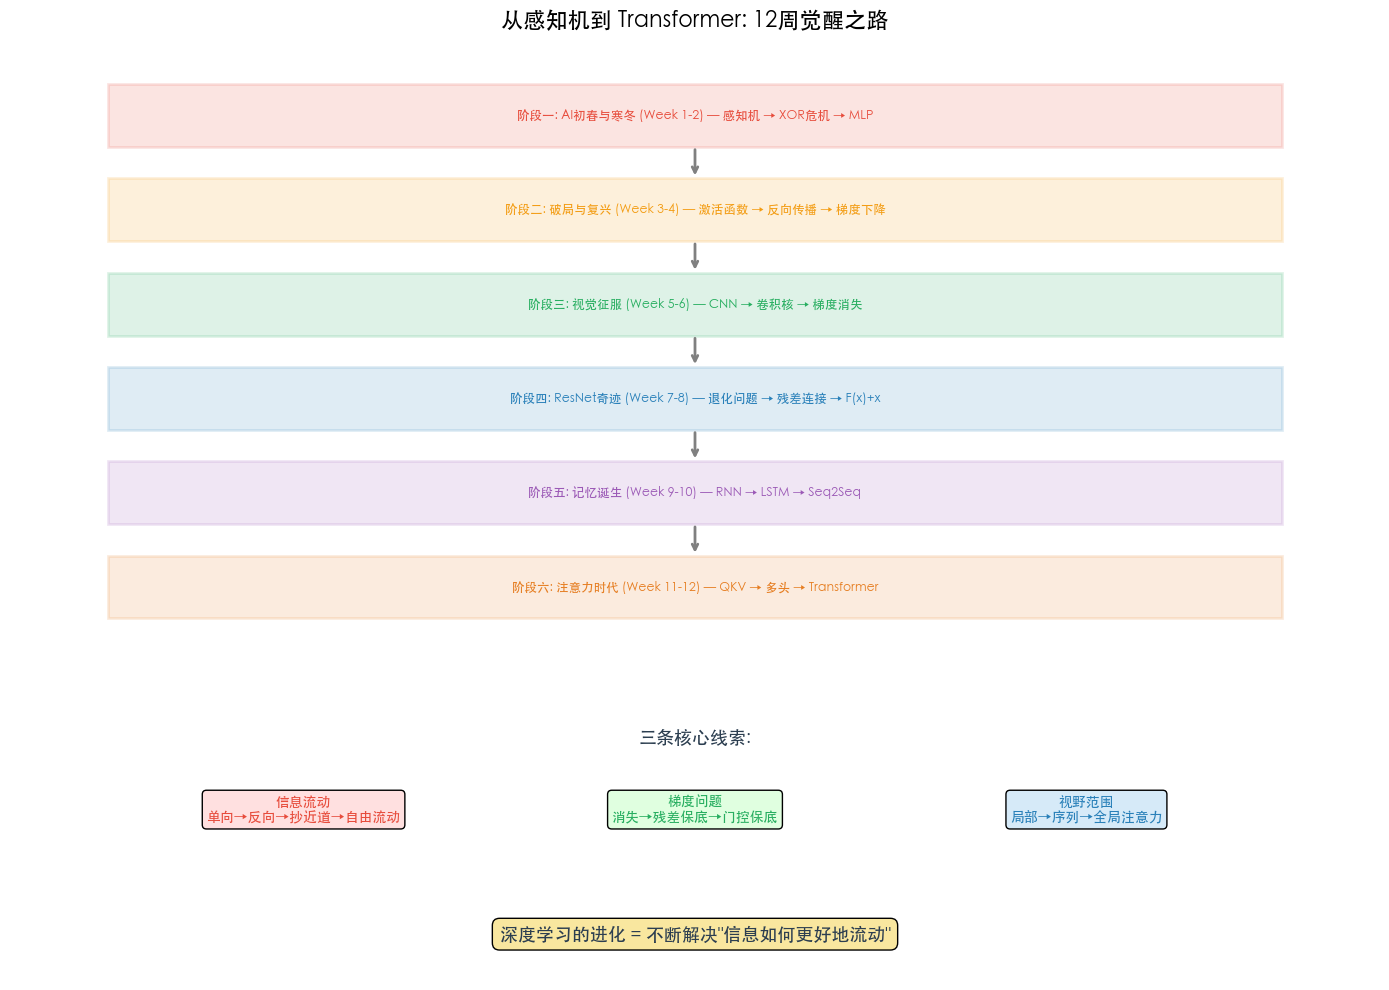</p>*12周觉醒之路全景图*

## 今日结语12 周的课程到此结束。我们从最简单的感知机出发，一路走到了改变世界的 Transformer。回顾这段旅程，每一次突破都源于对前一个痛点的深刻理解：- XOR 问题 → 多层网络 + 反向传播- 参数爆炸 → CNN 的权值共享- 深度退化 → ResNet 的残差连接- 金鱼记忆 → LSTM 的门控机制- 信息瓶颈 → 注意力机制- 串行瓶颈 → Transformer 的并行计算**深度学习的进化，就是不断解决"信息如何更好地流动"的过程。**感谢你走完这段旅程。这不是终点，而是起点——从这里出发，你已经有能力去理解 GPT、BERT、Stable Diffusion 等最前沿的 AI 技术。---### 翻译词典| 生活中的直觉 | 深度学习术语 ||---|---|| 信息抄近道 | 残差连接 || 记忆高速公路 | LSTM 细胞状态 || 信息自由流动 | Transformer 注意力 || 从局部到全局 | 从感知机到 Transformer 的进化 || 每次突破都解决一个痛点 | 深度学习的进化逻辑 || 这不是终点，而是起点 | 12 周课程的结束 = AI 之路的开始 |